In [1]:
import pandas as pd

# Column names - the file has NO headers so we define them manually
cols = ['engine_id', 'cycle', 
        'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
       [f'sensor_{i}' for i in range(1, 22)]

# Load training data
train_df = pd.read_csv('../data/raw/train_FD001.txt', 
                        sep=r'\s+', header=None, names=cols)

print("Shape:", train_df.shape)
print("\nFirst 3 rows:")
print(train_df.head(3))
print("\nUnique engines:", train_df['engine_id'].nunique())
print("\nAny NaNs?", train_df.isnull().sum().any())

Shape: (20631, 26)

First 3 rows:
   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0          1      1       -0.0007       -0.0004         100.0    518.67   
1          1      2        0.0019       -0.0003         100.0    518.67   
2          1      3       -0.0043        0.0003         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   
2    642.35   1587.99   1404.20     14.62  ...     522.42    2388.03   

   sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
0    8138.62     8.4195       0.03        392       2388      100.0   
1    8131.49     8.4318       0.03        392       2388      100.0   
2    8133.23     8.4178       0.03        390       2388      100.0   

   sensor_20  sensor_21  
0      39.06    23.4190  
1      39.00    23.4236  
2      38.95 

In [2]:
# Find the last cycle for each engine (= when it failed)
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# Merge back and compute RUL
train_df = train_df.merge(max_cycles, on='engine_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# Drop max_cycle column - we don't need it anymore
train_df.drop(columns=['max_cycle'], inplace=True)

# Sanity check
print("RUL range:", train_df['RUL'].min(), "to", train_df['RUL'].max())
print("\nEngine 1 - last 5 cycles:")
print(train_df[train_df['engine_id']==1].tail(5)[['engine_id','cycle','RUL']])

RUL range: 0 to 361

Engine 1 - last 5 cycles:
     engine_id  cycle  RUL
187          1    188    4
188          1    189    3
189          1    190    2
190          1    191    1
191          1    192    0


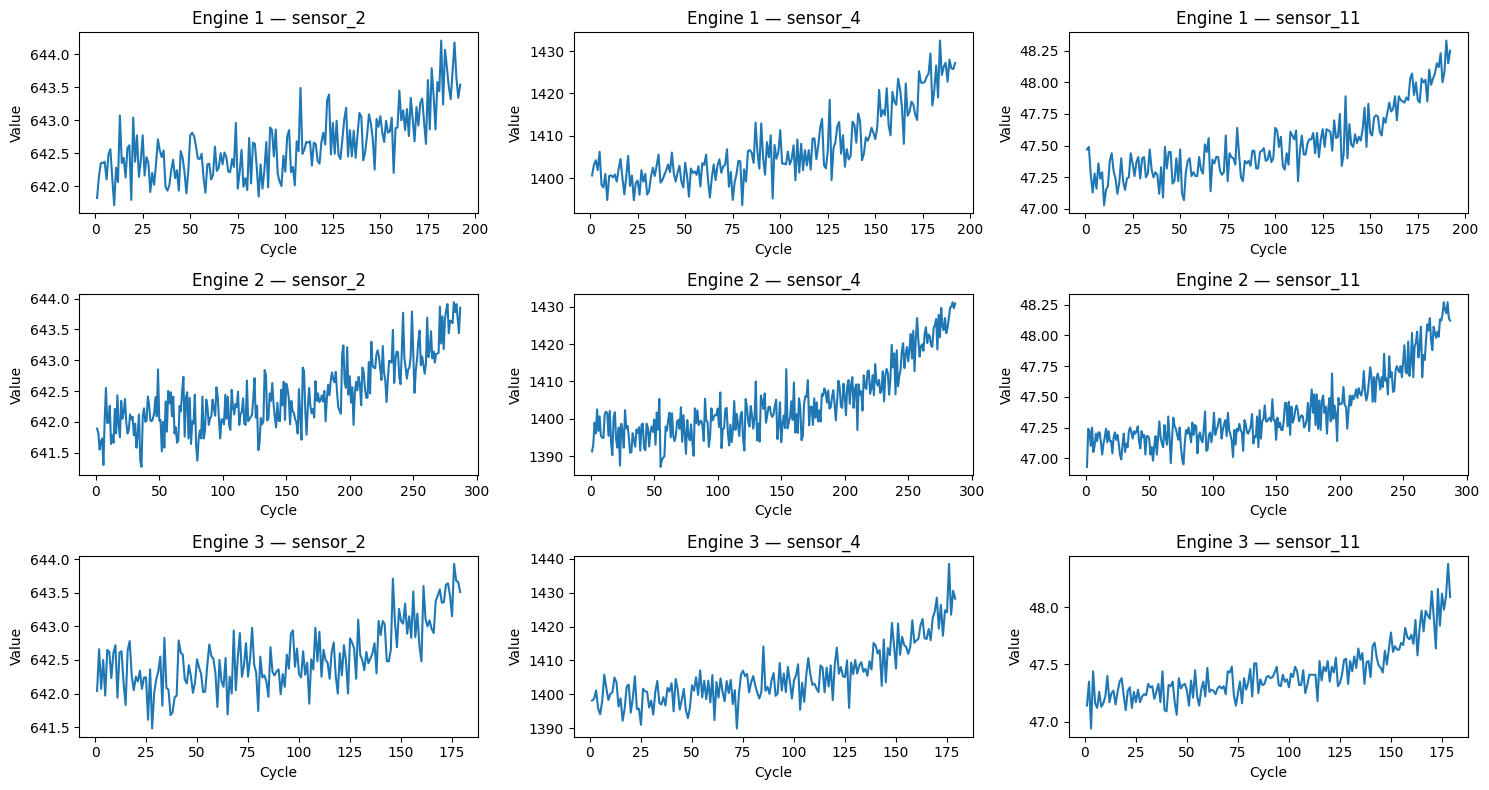

In [3]:
import matplotlib.pyplot as plt

# Plot 3 sensors for 3 different engines
sensors_to_plot = ['sensor_2', 'sensor_4', 'sensor_11']
engines_to_plot = [1, 2, 3]

fig, axes = plt.subplots(3, 3, figsize=(15, 8))

for row, eng in enumerate(engines_to_plot):
    eng_data = train_df[train_df['engine_id'] == eng]
    for col, sensor in enumerate(sensors_to_plot):
        axes[row, col].plot(eng_data['cycle'], eng_data[sensor])
        axes[row, col].set_title(f'Engine {eng} — {sensor}')
        axes[row, col].set_xlabel('Cycle')
        axes[row, col].set_ylabel('Value')

plt.tight_layout()
plt.savefig('../outputs/sensor_trends.png')
plt.show()

In [4]:
# Check which sensors have near-zero variance (flat = useless)
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]

variance = train_df[sensor_cols].var()
print("Sensor variances (sorted):")
print(variance.sort_values())

Sensor variances (sorted):
sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.203765e-35
sensor_5     2.840037e-29
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64


In [5]:
from sklearn.preprocessing import MinMaxScaler

# Drop flat/useless sensors
flat_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 
                'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

train_df.drop(columns=flat_sensors, inplace=True)
print("Remaining columns:", train_df.shape[1])

# Define the useful sensor columns
sensor_cols = [c for c in train_df.columns 
               if c.startswith('sensor_')]
print("Useful sensors:", sensor_cols)

# Normalize sensors to [0,1] - important before tsfresh
scaler = MinMaxScaler()
train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])

print("\nSample after normalization:")
print(train_df[sensor_cols].head(3).round(4))

Remaining columns: 20
Useful sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Sample after normalization:
   sensor_2  sensor_3  sensor_4  sensor_7  sensor_8  sensor_9  sensor_11  \
0    0.1837    0.4068    0.3098    0.7262    0.2424    0.1098      0.369   
1    0.2831    0.4530    0.3526    0.6280    0.2121    0.1002      0.381   
2    0.3434    0.3695    0.3705    0.7101    0.2727    0.1400      0.250   

   sensor_12  sensor_13  sensor_14  sensor_15  sensor_17  sensor_20  sensor_21  
0     0.6333     0.2059     0.1996     0.3640     0.3333     0.7132     0.7247  
1     0.7655     0.2794     0.1628     0.4113     0.3333     0.6667     0.7310  
2     0.7953     0.2206     0.1718     0.3574     0.1667     0.6279     0.6214  


In [6]:
import os
os.makedirs('../data/processed', exist_ok=True)

train_df.to_csv('../data/processed/train_FD001_preprocessed.csv', index=False)
print("Saved! Shape:", train_df.shape)
print("Columns:", list(train_df.columns))

Saved! Shape: (20631, 20)
Columns: ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']


In [7]:
import joblib
os.makedirs('../models', exist_ok=True)

joblib.dump(scaler, '../models/minmax_scaler.pkl')
print("Scaler saved.")

Scaler saved.


## Notebook 01 — Exploration & Preprocessing

- Loaded FD001 training data (20,631 rows, 100 engines)
- Computed RUL as max_cycle - current_cycle (range: 0–361)
- Identified and dropped 7 flat/zero-variance sensors
- Normalized 14 remaining sensors to [0,1] with MinMaxScaler
- Saved preprocessed data to data/processed/